# 07 - Benchmark comparison and diagnostics

Loads the precomputed public benchmark tables and produces comparison
tables/plots. Fully executable on the public data included in this
repository (no model re-runs required).


In [1]:
import sys

import pandas as pd

sys.path.insert(0, "../src")

summary = pd.read_csv("../results_public/chlorophyll/chlorophyll_benchmark_summary.csv")
scores = pd.read_csv("../results_public/chlorophyll/chlorophyll_artificial_gap_scores.csv")
summary


,method_family,method_public_name,compared_against_public_name,stratum,n_gaps,n_bootstrap_replicates,metric,method_value,comparison_value,delta,ci_lo,ci_hi,interpretation,evidence_tier
0,foundation_model_zero_shot,TS-ICL (satellite chlorophyll proxy covariate),Linear interpolation baseline,all_gaps,680,2000,day_weighted_mae,0.2432,0.2706,-0.0274,-0.0359,-0.0185,significant_improvement,"validation-grade (artificial-gap pool, n=680-681)"
1,foundation_model_zero_shot,TS-ICL (satellite chlorophyll proxy covariate),Gaussian process (time-only),all_gaps,681,2000,day_weighted_mae,0.2432,0.2628,-0.0196,-0.0257,-0.0139,significant_improvement,"validation-grade (artificial-gap pool, n=680-681)"
2,foundation_model_zero_shot,TS-ICL (satellite chlorophyll proxy covariate),Engineered hybrid pipeline (validation-aware m...,all_gaps,681,2000,day_weighted_mae,0.2432,0.2601,-0.0169,-0.0244,-0.0101,significant_improvement,"validation-grade (artificial-gap pool, n=680-681)"
3,foundation_model_zero_shot,TS-ICL (satellite chlorophyll proxy covariate),"TS-ICL (target-only, no covariates)",all_gaps,681,2000,day_weighted_mae,0.2432,0.2505,-0.0073,-0.0098,-0.0048,significant_improvement,"validation-grade (artificial-gap pool, n=680-681)"
4,foundation_model_zero_shot,TS-ICL (wind/upwelling forcing covariate),"TS-ICL (target-only, no covariates)",all_gaps,681,2000,day_weighted_mae,0.2477,0.2505,-0.0028,-0.0067,0.0011,directional_not_significant,"validation-grade (artificial-gap pool, n=681)"
5,foundation_model_zero_shot,TS-ICL (curated physical-forcing covariate set),"TS-ICL (target-only, no covariates)",all_gaps,681,2000,day_weighted_mae,0.2469,0.2505,-0.0036,-0.0063,-0.0010,significant_improvement,"validation-grade (artificial-gap pool, n=681)"
6,foundation_model_zero_shot,TS-ICL (wind/upwelling forcing covariate),Linear interpolation baseline,all_gaps,680,2000,day_weighted_mae,0.2477,0.2706,-0.0229,-0.0321,-0.0137,significant_improvement,"validation-grade (artificial-gap pool, n=681)"
7,foundation_model_zero_shot,TS-ICL (curated physical-forcing covariate set),Linear interpolation baseline,all_gaps,680,2000,day_weighted_mae,0.2469,0.2706,-0.0237,-0.0329,-0.0145,significant_improvement,"validation-grade (artificial-gap pool, n=681)"
8,foundation_model_zero_shot,TS-ICL (ocean current/transport covariate),"TS-ICL (target-only, no covariates)",all_gaps,681,2000,day_weighted_mae,0.2617,0.2505,0.0112,0.0077,0.0150,significant_degradation,"validation-grade (artificial-gap pool, n=681)"
9,baseline,Monthly climatology baseline,Linear interpolation baseline,all_gaps,680,2000,day_weighted_mae,0.3515,0.2706,0.0809,0.0654,0.0971,significant_degradation,validation-grade baseline


## Overall comparison: TS-ICL satellite-proxy vs. other methods

In [2]:
summary[["method_public_name", "compared_against_public_name", "delta", "ci_lo", "ci_hi", "interpretation"]]


,method_public_name,compared_against_public_name,delta,ci_lo,ci_hi,interpretation
0,TS-ICL (satellite chlorophyll proxy covariate),Linear interpolation baseline,-0.0274,-0.0359,-0.0185,significant_improvement
1,TS-ICL (satellite chlorophyll proxy covariate),Gaussian process (time-only),-0.0196,-0.0257,-0.0139,significant_improvement
2,TS-ICL (satellite chlorophyll proxy covariate),Engineered hybrid pipeline (validation-aware m...,-0.0169,-0.0244,-0.0101,significant_improvement
3,TS-ICL (satellite chlorophyll proxy covariate),"TS-ICL (target-only, no covariates)",-0.0073,-0.0098,-0.0048,significant_improvement
4,TS-ICL (wind/upwelling forcing covariate),"TS-ICL (target-only, no covariates)",-0.0028,-0.0067,0.0011,directional_not_significant
5,TS-ICL (curated physical-forcing covariate set),"TS-ICL (target-only, no covariates)",-0.0036,-0.0063,-0.0010,significant_improvement
6,TS-ICL (wind/upwelling forcing covariate),Linear interpolation baseline,-0.0229,-0.0321,-0.0137,significant_improvement
7,TS-ICL (curated physical-forcing covariate set),Linear interpolation baseline,-0.0237,-0.0329,-0.0145,significant_improvement
8,TS-ICL (ocean current/transport covariate),"TS-ICL (target-only, no covariates)",0.0112,0.0077,0.0150,significant_degradation
9,Monthly climatology baseline,Linear interpolation baseline,0.0809,0.0654,0.0971,significant_degradation


**Support**: the table above (`chlorophyll_benchmark_summary.csv`) is on
the **full 681-gap pool** (n_gaps reported as 680-681 depending on which
gaps a given comparator has a prediction for). This is the support TS-ICL's
own paired/bootstrap comparisons and the covariate-mechanism ranking below
use.

For a direct comparison against the classical/probabilistic/gap-edge
methods in `experiments/chlorophyll/benchmark_contract.py`, use the
**matched 449-gap support** instead
(`results_public/chlorophyll/chlorophyll_matched_support_method_metrics.csv`,
`method_id` in `{tsicl_target_only, tsicl_satellite_proxy}`) -- it is the
only support every one of those methods and TS-ICL both have a released
row on; the classical methods beyond interpolation/GP have no row on the
full 681-gap pool. See `experiments/chlorophyll/tsicl_contract.py` for the
exact, tested support definitions.

## Performance by gap length

In [3]:
by_length = scores[scores["stratum_type"] == "gap_length"]
pivot = by_length.pivot_table(index="stratum_value", columns="method_public_name", values="day_weighted_mae")
pivot


method_public_name,Engineered hybrid pipeline (validation-aware method assignment),Gaussian process (time-only),Linear interpolation baseline,Monthly climatology baseline,TS-ICL (curated physical-forcing covariate set),TS-ICL (ocean current/transport covariate),TS-ICL (satellite chlorophyll proxy covariate),"TS-ICL (target-only, no covariates)",TS-ICL (wind/upwelling forcing covariate)
stratum_value,,,,,,,,,
L=1,0.1037,0.1037,0.1077,0.3720,0.10365,0.1344,0.10595,0.1060,0.1102
L=10,0.2233,0.2273,0.2252,0.3458,0.21330,0.2224,0.20880,0.2134,0.2094
L=14,0.2523,0.2481,0.2535,0.3445,0.23430,0.2489,0.23450,0.2385,0.2301
L=21,0.2754,0.2755,0.2747,0.3488,0.25650,0.2785,0.25310,0.2607,0.2583
L=3,0.1290,0.1290,0.1329,0.3657,0.12260,0.1311,0.12220,0.1231,0.1202
L=30,0.2651,0.2660,0.2779,0.3541,0.25430,0.2710,0.25420,0.2594,0.2566
L=45,0.3173,0.3065,0.3578,0.3652,0.30030,0.3108,0.29230,0.3030,0.3062
L=60,0.2938,0.3190,0.3094,0.3459,0.28360,0.2980,0.27660,0.2906,0.2874
L=7,0.1891,0.1989,0.1904,0.3510,0.18600,0.1970,0.17960,0.1860,0.1830


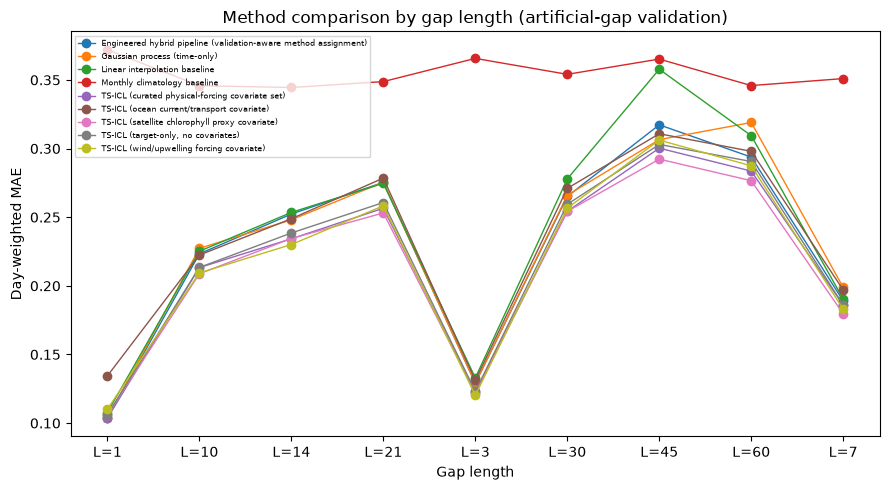

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
for method in pivot.columns:
    ax.plot(pivot.index, pivot[method], marker="o", label=method, lw=1)
ax.set_xlabel("Gap length")
ax.set_ylabel("Day-weighted MAE")
ax.legend(fontsize=6, loc="upper left")
ax.set_title("Method comparison by gap length (artificial-gap validation)")
plt.tight_layout()
plt.show()


## Performance by season

In [5]:
by_season = scores[scores["stratum_type"] == "season"]
by_season.pivot_table(index="stratum_value", columns="method_public_name", values="day_weighted_mae")


method_public_name,Engineered hybrid pipeline (validation-aware method assignment),Gaussian process (time-only),Linear interpolation baseline,Monthly climatology baseline,TS-ICL (curated physical-forcing covariate set),TS-ICL (ocean current/transport covariate),TS-ICL (satellite chlorophyll proxy covariate),"TS-ICL (target-only, no covariates)",TS-ICL (wind/upwelling forcing covariate)
stratum_value,,,,,,,,,
DJF,0.29780,0.29380,0.3045,0.4048,0.28780,0.3006,0.28170,0.2850,0.28260
JJA,0.19885,0.18875,0.2052,0.3000,0.17355,0.1996,0.16845,0.1805,0.18335
MAM,0.23790,0.26080,0.2490,0.3520,0.23920,0.2517,0.23710,0.2479,0.24240
SON,0.28860,0.28950,0.3058,0.3343,0.26760,0.2780,0.26610,0.2707,0.26540


## Event vs. non-event performance

In [6]:
event_perf = pd.read_csv("../results_public/chlorophyll/chlorophyll_event_performance_summary.csv")
event_perf[["method_public_name", "mae_event_days", "mae_nonevent_days", "event_penalty_mae_event_minus_nonevent"]]


,method_public_name,mae_event_days,mae_nonevent_days,event_penalty_mae_event_minus_nonevent
0,Linear interpolation baseline,0.3229,0.2295,0.0934
1,Monthly climatology baseline,0.3476,0.3546,-0.0070
2,Gaussian process (time-only),0.3158,0.2212,0.0945
3,Engineered hybrid pipeline (validation-aware m...,0.3087,0.2219,0.0868
4,Gap-edge residual model (deployed),0.2806,0.2046,0.0759
5,"TS-ICL (target-only, no covariates)",0.3010,0.2108,0.0902
6,TS-ICL (satellite chlorophyll proxy covariate),0.2916,0.2052,0.0864
7,TS-ICL (wind/upwelling forcing covariate),0.2998,0.2066,0.0932
8,TS-ICL (curated physical-forcing covariate set),0.2991,0.2058,0.0934
9,TS-ICL (ocean current/transport covariate),0.3136,0.2209,0.0927


## Covariate mechanism

Which covariates actually help, and which are merely correlated noise?
See `docs/methodology/model_families.md` and the placebo-test rows in the
covariate mechanism table below.


In [7]:
covariate_summary = pd.read_csv("../results_public/chlorophyll/chlorophyll_covariate_mechanism_summary.csv")
covariate_summary[covariate_summary["table_section"] == "covariate_arm_performance"][
    ["covariate_public_name", "n_gaps", "mae_mean", "rmse_mean", "bias_mean"]
].sort_values("mae_mean")


,covariate_public_name,n_gaps,mae_mean,rmse_mean,bias_mean
0,Solar x upwelling interaction,681,0.1981,0.2325,-0.0015
1,Upwelling x SST cooling interaction,681,0.1985,0.2336,-0.0060
2,Wind/upwelling forcing only,681,0.1985,0.2332,0.0063
3,Curated low-redundancy physical set,681,0.1988,0.2335,-0.0112
4,Satellite chlorophyll proxy + wind/upwelling,681,0.1993,0.2341,0.0092
5,Satellite chlorophyll proxy + availability proxy,681,0.1995,0.2345,-0.0030
6,Satellite chlorophyll proxy + solar,681,0.1997,0.2350,-0.0019
7,Satellite chlorophyll proxy + PLV meteorological,681,0.2010,0.2361,-0.0052
8,No covariate (target-only baseline),681,0.2014,0.2359,-0.0048
9,Solar radiation only,681,0.2015,0.2365,-0.0028


In [8]:
covariate_summary[covariate_summary["table_section"] == "placebo_robustness_test"]


,table_section,covariate_public_name,n_gaps,mae_mean,rmse_mean,bias_mean,evidence_note,comparison,context_mode,delta_mae_mean,delta_mae_ci_lo,delta_mae_ci_hi,significant
18,placebo_robustness_test,NaN,671,NaN,NaN,NaN,NaN,Curated physical-forcing covariate vs. randomi...,full_series,-0.00226,-0.00410,-0.00048,True
19,placebo_robustness_test,NaN,671,NaN,NaN,NaN,NaN,Curated physical-forcing covariate vs. randomi...,full_series,-0.00404,-0.00593,-0.00224,True
20,placebo_robustness_test,NaN,671,NaN,NaN,NaN,NaN,Curated physical-forcing covariate vs. randomi...,edge_balanced,-0.00178,-0.00336,-0.00025,True
21,placebo_robustness_test,NaN,671,NaN,NaN,NaN,NaN,Curated physical-forcing covariate vs. randomi...,edge_balanced,-0.00281,-0.00453,-0.00119,True


## Reproducing these numbers, not just loading them

Every table above is a frozen, already-released result -- this notebook
never re-runs a model. To regenerate the underlying TS-ICL predictions
yourself (requires the separate `.venv_tsicl` environment,
`docs/methodology/tsicl_usage.md`):

```bash
PYTHONPATH=src .venv_tsicl/bin/python -m experiments.chlorophyll.run_tsicl_benchmark \
    --support matched_449 --arms target_only,satellite_proxy \
    --context-modes full_series --out build/chlorophyll/tsicl_benchmark

PYTHONPATH=src .venv_tsicl/bin/python -m experiments.chlorophyll.run_tsicl_covariate_analysis \
    --arms curated_physical,satellite_proxy --support matched_449 \
    --out build/chlorophyll/tsicl_covariates
```

Both drivers are restart-safe and checkpoint-verified
(`coastal_gap_reconstruction.tsicl_helpers.load_tsicl_strict` fails loudly
on any checkpoint/package mismatch rather than silently proceeding), and
write their own `RUN_STATUS`/`run_metadata.json` with full provenance --
they never overwrite the `results_public/` tables loaded above. Freshly
generated predictions are environment-sensitive (see "What reproduces
exactly, what is environment-sensitive" in `docs/methodology/
tsicl_usage.md`); compare them against the frozen tables using the
evidence your own run actually produces, not an assumed tolerance. The
classical/probabilistic comparators' own reproduction status is separately
documented in `docs/methodology/validation_protocol.md` -- do not describe
that as fully reproduced when its own verification status is partial.